<a href="https://colab.research.google.com/github/jeananalaufy/Oil_Gas_Prediction/blob/main/Oman_Oil_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project Overview - Oman Oil Production Forecasting


*A Comparative Study of Machine Learning Models for Oil Production Forecasting in Support of Oman's Digital Transformation and Vision 2040*

*Goal: Which machine learning model provides the most accurate forecasting of Oman's monthly oil production using publicly available data?*


## Objectives

1. Explore and understand the dataset.
2. Clean and preprocess the data.
3. Develop multiple machine learning models.
4. Compare model performance.
5. Discuss implications for Oman's energy sector and Vision 2040.


# Import Libraries

Import the Python libraries required for data manipulation, visualization and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Upload Dataset

Upload the official Oman Open Data oil production dataset.

In [ ]:
df = pd.read_excel("Oil Production.xlsx")

# Exploratory Data Analysis (EDA)

Before cleaning or modelling, we explore the dataset to understand:

- Number of observations
- Number of variables
- Data types
- Missing values
- Overall statistics





In [ ]:
df.head()

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL)
0,2021-01-01,29713.40,22644,7069.20,958.50,43.80
1,2022-12-01,32961.71,25939,7021.81,1063.28,90.79
2,2020-12-01,29324.70,22395,6929.00,946.00,41.10
3,2020-10-01,29273.10,22354,6919.00,944.30,44.30
4,2021-03-01,29524.80,22637,6887.20,952.40,54.80


In [ ]:
#Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Month                     195 non-null    datetime64[ns]
 1   Total                     195 non-null    float64       
 2   Crude Oil                 195 non-null    int64         
 3   Condensate                195 non-null    float64       
 4   Daily Average Production  195 non-null    float64       
 5   Average Price (US$/BBL)   195 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 9.3 KB


In [ ]:
#Summary statistics
df.describe()

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL)
count,195,195.000000,195.000000,195.000000,195.000000,195.000000
mean,2014-10-31 13:17:32.307692288,27923.851590,24360.682051,3562.701077,917.136821,75.193179
min,2006-10-01 00:00:00,20096.600000,18561.000000,1443.800000,693.000000,23.700000
25%,2010-10-16 12:00:00,26353.950000,22367.000000,2758.850000,868.600000,55.900000
50%,2014-11-01 00:00:00,28872.800000,24894.000000,3122.600000,947.400000,71.700000
75%,2018-11-16 00:00:00,29985.400000,26499.500000,3560.450000,972.900000,100.400000
max,2022-12-01 00:00:00,33944.200000,29018.000000,7069.200000,1108.400000,133.100000
std,NaN,3024.255713,2578.231761,1465.613463,95.942578,24.710331


In [ ]:
#Missing values
df.isnull().sum()

,0
Month,0
Total,0
Crude Oil,0
Condensate,0
Daily Average Production,0
Average Price (US$/BBL),0


# Initial Observations

- The dataset contains **195 monthly observations**.
- The data spans **October 2006 to December 2022**.
- There are **five numerical variables**:
  - Total
  - Crude Oil
  - Condensate
  - Daily Average Production
  - Average Price
- There are no missing values.
- The dataset appears suitable for machine learning and time-series forecasting.

#**Data Visualization**

# Data Visualization

This section explores the dataset visually to identify trends, patterns, relationships, and potential anomalies before building machine learning models.

The following visualizations are included:

- Total Oil Production over Time
- Average Oil Price over Time
- Correlation Matrix
- Distribution of Variables (Histograms)

## 1. Total Monthly Oil Production

This plot illustrates how total monthly oil production has changed over time.

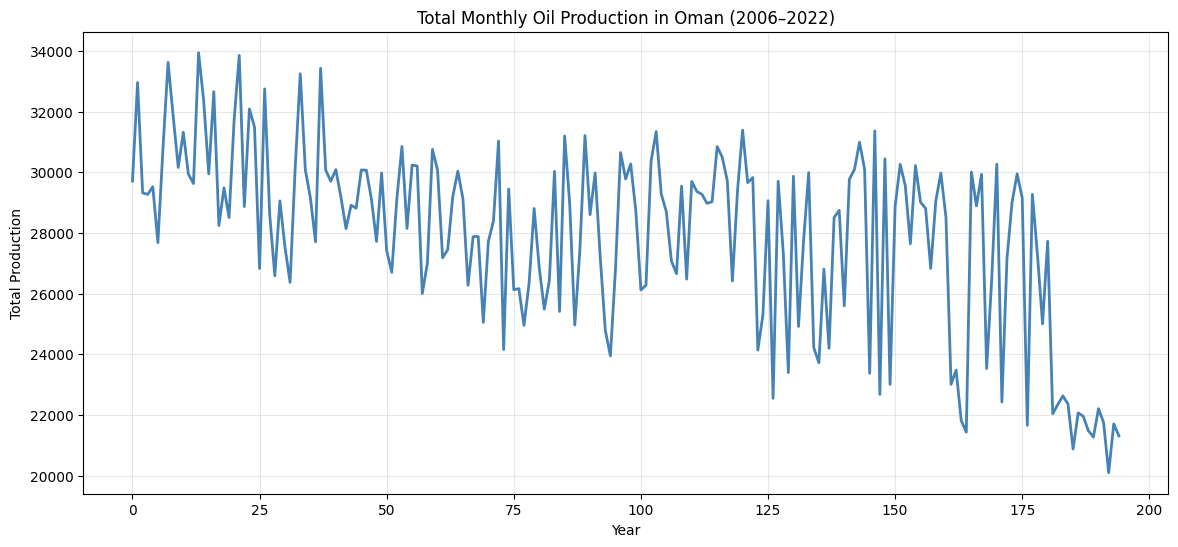

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Total"], color="steelblue", linewidth=2)

plt.title("Total Monthly Oil Production in Oman (2006–2022)")
plt.xlabel("Year")
plt.ylabel("Total Production")

plt.grid(alpha=0.3)

plt.show()

## 2. Average Oil Price Over Time

This plot shows the monthly average oil price over the study period.

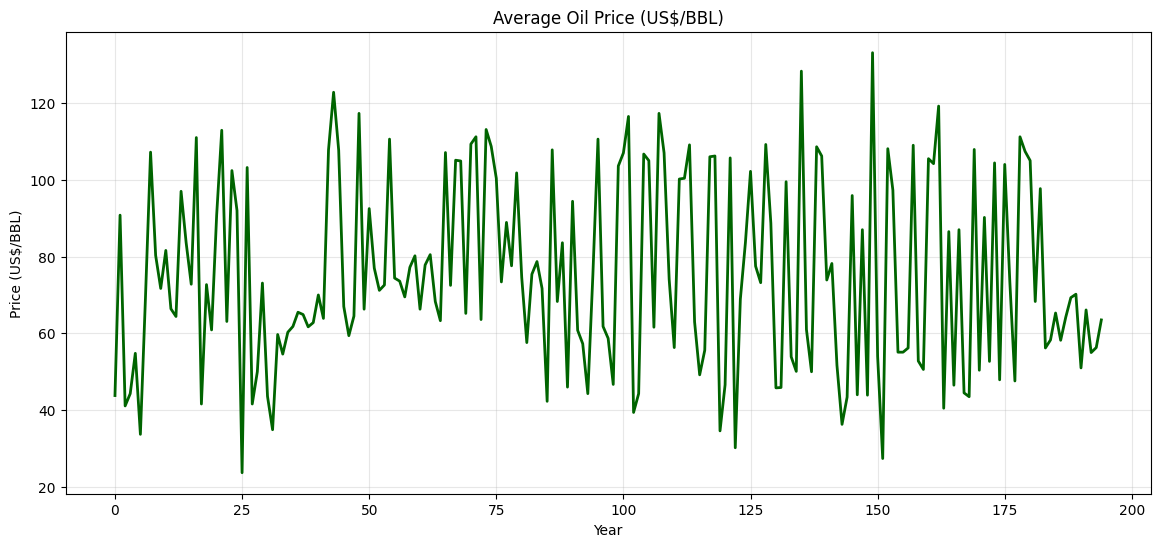

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Average Price (US$/BBL)"], color="darkgreen", linewidth=2)

plt.title("Average Oil Price (US$/BBL)")
plt.xlabel("Year")
plt.ylabel("Price (US$/BBL)")

plt.grid(alpha=0.3)

plt.show()

## 3. Correlation Matrix

The correlation matrix helps identify relationships between numerical variables.

In [ ]:
correlation = df.corr()

correlation

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL)
Month,1.000000,0.831748,0.547959,0.752340,0.858350,-0.248321
Total,0.831748,1.000000,0.875013,0.524187,0.969004,-0.050538
Crude Oil,0.547959,0.875013,1.000000,0.046411,0.838856,-0.021469
Condensate,0.752340,0.524187,0.046411,1.000000,0.523838,-0.066544
Daily Average Production,0.858350,0.969004,0.838856,0.523838,1.000000,-0.062969
Average Price (US$/BBL),-0.248321,-0.050538,-0.021469,-0.066544,-0.062969,1.000000


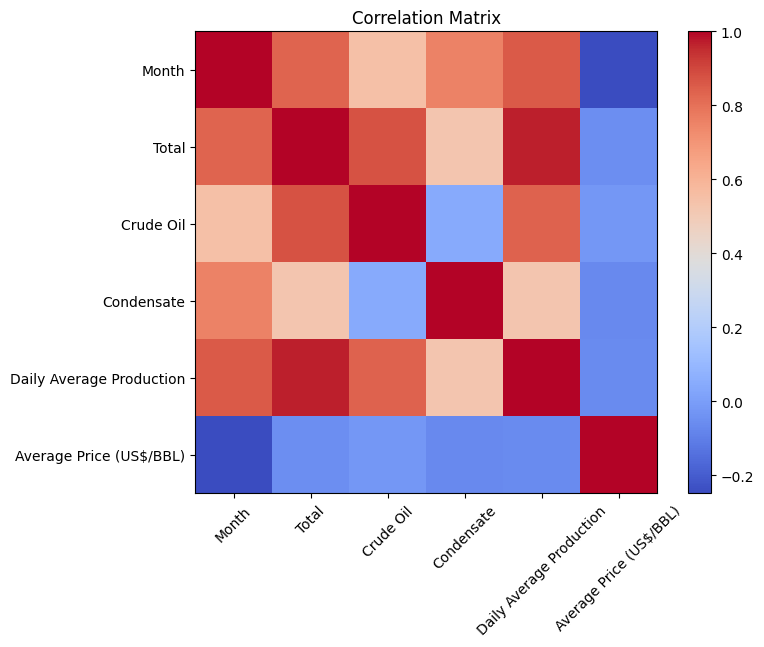

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

## 3. Distribution of Variables

Histograms help us understand how each variable is distributed and identify potential skewness or unusual values.

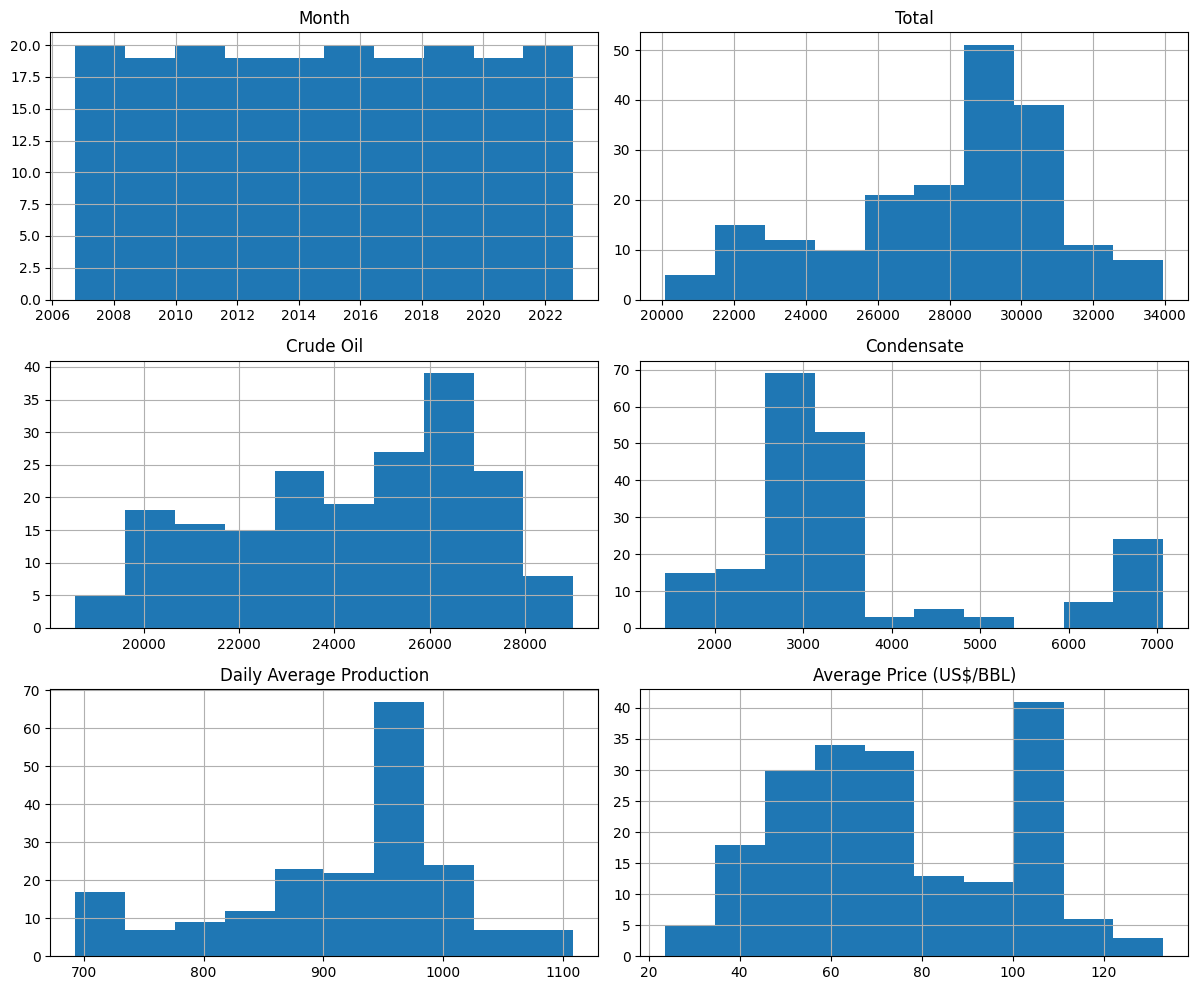

In [ ]:
df.hist(figsize=(12,10))

plt.tight_layout()

plt.show()

# **Data Cleaning**

Before applying machine learning models, the dataset was checked for common data quality issues.

The following checks were performed:

- Missing values
- Duplicate observations
- Data types

Since this is an official government dataset, only minimal cleaning is expected.

In [ ]:
# Missing values
df.isnull().sum()

,0
Month,0
Total,0
Crude Oil,0
Condensate,0
Daily Average Production,0
Average Price (US$/BBL),0


In [ ]:
# Duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Data types
df.dtypes

,0
Month,datetime64[ns]
Total,float64
Crude Oil,int64
Condensate,float64
Daily Average Production,float64
Average Price (US$/BBL),float64


Data Cleaning Summary

The dataset required minimal preprocessing.

Key observations:

- No missing values were identified.
- No duplicate observations were detected.
- Numerical variables were already stored in appropriate formats.
- The Month column was successfully converted to a datetime index.
- The dataset is suitable for machine learning and time-series forecasting.

#Feature Engineering


Feature engineering is the process of creating or transforming variables to improve machine learning model performance.

For time-series forecasting, temporal features can help models identify trends and seasonal patterns.

The following features will be created:

- Year
- Month Number

In [ ]:
df["Year"] = df["Month"].dt.year
df["Month_Number"] = df["Month"].dt.month

df.head()

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL),Year,Month_Number
0,2021-01-01,29713.40,22644,7069.20,958.50,43.80,2021,1
1,2022-12-01,32961.71,25939,7021.81,1063.28,90.79,2022,12
2,2020-12-01,29324.70,22395,6929.00,946.00,41.10,2020,12
3,2020-10-01,29273.10,22354,6919.00,944.30,44.30,2020,10
4,2021-03-01,29524.80,22637,6887.20,952.40,54.80,2021,3


1. Feature Engineering Summary

Two additional features were created:

- **Year**: captures long-term trends in oil production.
- **Month_Number**: captures seasonal or monthly patterns.

These features may improve forecasting performance.

2. Defining the Prediction Problem

The objective is to predict **Total Monthly Oil Production**.

Target Variable:
- Total

Potential Input Features:
- Average Price
- Year
- Month_Number

Additional features may be added later if necessary.

In [ ]:
#Selecting features and targets

# Features (inputs)
X = df[["Average Price (US$/BBL)", "Year", "Month_Number"]]

# Target (output)
y = df["Total"]

# Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training set is used to train the models.

The testing set is used to evaluate how well the models perform on unseen data.

In [ ]:
#Train-test split

# Keep data in chronological order

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

**Model goal: Which model predicts historical data most accurately?**

#Machine Learning Models


# Model 1: Linear Regression

Linear Regression is used as the baseline model.

It provides a simple benchmark that later models will be compared against.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print(predictions)

[28077.97174426 27105.84279781 29056.21236188 29095.13751306
 27943.88628153 25778.94213948 26056.17073567 25062.03253622
 25256.08797122 29107.73844647 28616.68003217 28594.18797293
 25242.40873933 28212.1881838  29300.5840159  25446.16257036
 28777.20357923 28371.91367684 28379.41142344 28227.56008751
 25257.35958979 29192.38460745 27953.45311045 27318.72529426
 28310.82076334 25115.90853785 25619.47978065 24504.99710334
 24672.62684312 24796.72068598 24490.13376752 24712.07452501
 24921.54591618 25072.82693124 24251.5671883  24946.6162159
 24376.39241849 24575.78841287 24632.97030461]


Testing Model Performance

In [ ]:

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
156,28809.0,28077.971744
157,26832.0,27105.842798
158,29055.3,29056.212362
159,29977.0,29095.137513
160,28512.9,27943.886282
161,23010.3,25778.942139
162,23480.2,26056.170736
163,21817.1,25062.032536
164,21432.8,25256.087971
165,30011.3,29107.738446


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape*100:.2f}%")
print(f"R² Score: {r2:.4f}")

MAE: 2036.19
RMSE: 2382.29
MAPE: 8.92%
R² Score: 0.5238


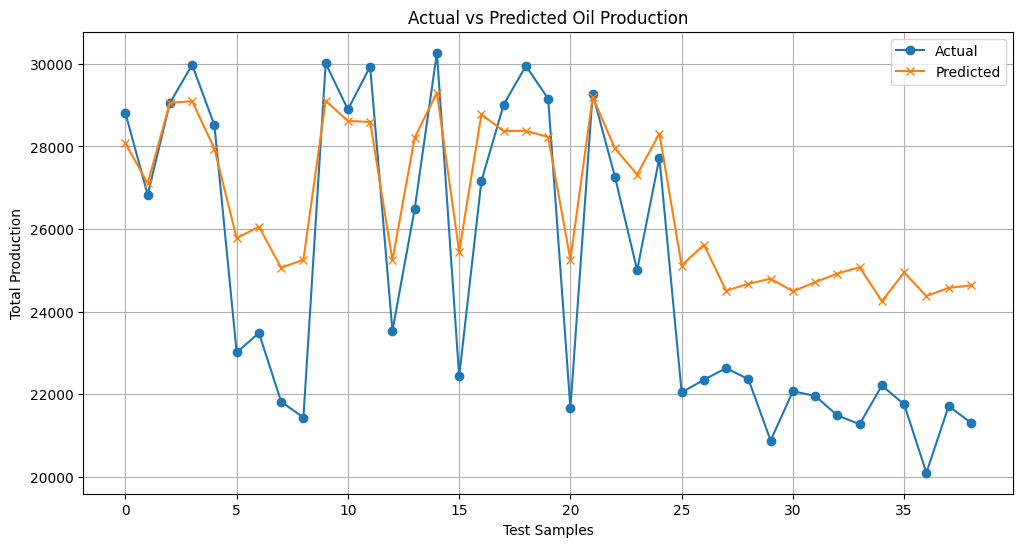

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual", marker="o")
plt.plot(predictions, label="Predicted", marker="x")

plt.title("Actual vs Predicted Oil Production")
plt.xlabel("Test Samples")
plt.ylabel("Total Production")

plt.legend()
plt.grid(True)

plt.show()

# Linear Regression Results

The Linear Regression model was trained using the selected input features to predict total monthly oil production.

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These results provide the baseline performance and will later be compared with Random Forest and XGBoost models.

# Model 2: Random Forest

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Linear Regression, Random Forest can model complex nonlinear relationships, making it well suited for oil production forecasting where production is influenced by multiple interacting factors.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_predictions = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

rf_mape = mean_absolute_percentage_error(
    y_test,
    rf_predictions
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAPE: {rf_mape*100:.2f}%")
print(f"R² Score: {rf_r2:.4f}")

MAE: 1219.33
RMSE: 1500.93
MAPE: 5.35%
R² Score: 0.8110


In [ ]:
rf_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_predictions
})

rf_comparison.head(10)

,Actual,Predicted
156,28809.0,29669.259
157,26832.0,26994.704
158,29055.3,30009.887
159,29977.0,30061.264
160,28512.9,28846.154
161,23010.3,23512.404
162,23480.2,23737.566
163,21817.1,24600.095
164,21432.8,23047.498
165,30011.3,29850.383


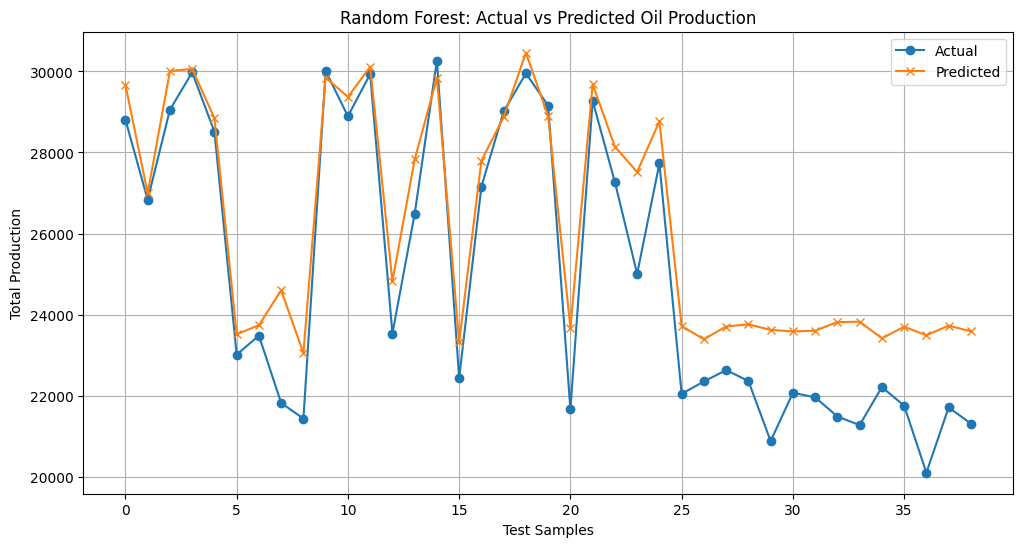

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual",
    marker="o"
)

plt.plot(
    rf_predictions,
    label="Predicted",
    marker="x"
)

plt.title("Random Forest: Actual vs Predicted Oil Production")

plt.xlabel("Test Samples")

plt.ylabel("Total Production")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Year,0.803132
0,Average Price (US$/BBL),0.115220
2,Month_Number,0.081648


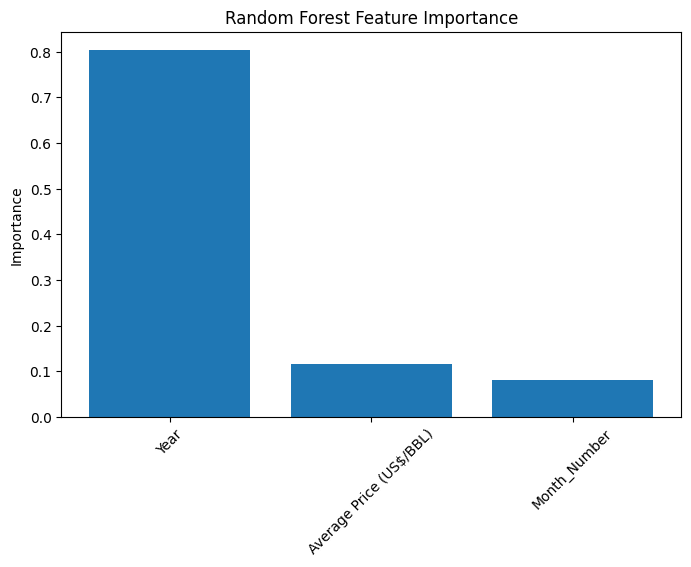

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

Random Forest Results

The Random Forest model was trained using the selected input features to predict total monthly oil production.

The model was evaluated using:

• Mean Absolute Error (MAE)
• Root Mean Squared Error (RMSE)
• Mean Absolute Percentage Error (MAPE)
• R² Score

The performance of Random Forest will later be compared with Linear Regression and XGBoost to identify the most accurate forecasting model for Oman's monthly oil production.

Model 3: XGBoost

Extreme Gradient Boosting (XGBoost) is an advanced ensemble machine learning algorithm that builds decision trees sequentially, with each tree improving the errors made by the previous one.

XGBoost is widely used in prediction problems because it provides high accuracy, efficiently handles nonlinear relationships, and reduces overfitting through regularisation techniques.

In [ ]:
!pip install xgboost
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_predictions = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_predictions
) ** 0.5

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print(f"MAE: {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAPE: {xgb_mape*100:.2f}%")
print(f"R² Score: {xgb_r2:.4f}")

MAE: 942.92
RMSE: 1174.90
MAPE: 4.15%
R² Score: 0.8842


In [ ]:
xgb_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgb_predictions
})

xgb_comparison.head(10)

,Actual,Predicted
156,28809.0,29615.492188
157,26832.0,26881.517578
158,29055.3,29606.296875
159,29977.0,30007.476562
160,28512.9,28941.154297
161,23010.3,23211.031250
162,23480.2,23641.232422
163,21817.1,23328.347656
164,21432.8,22117.666016
165,30011.3,29493.203125


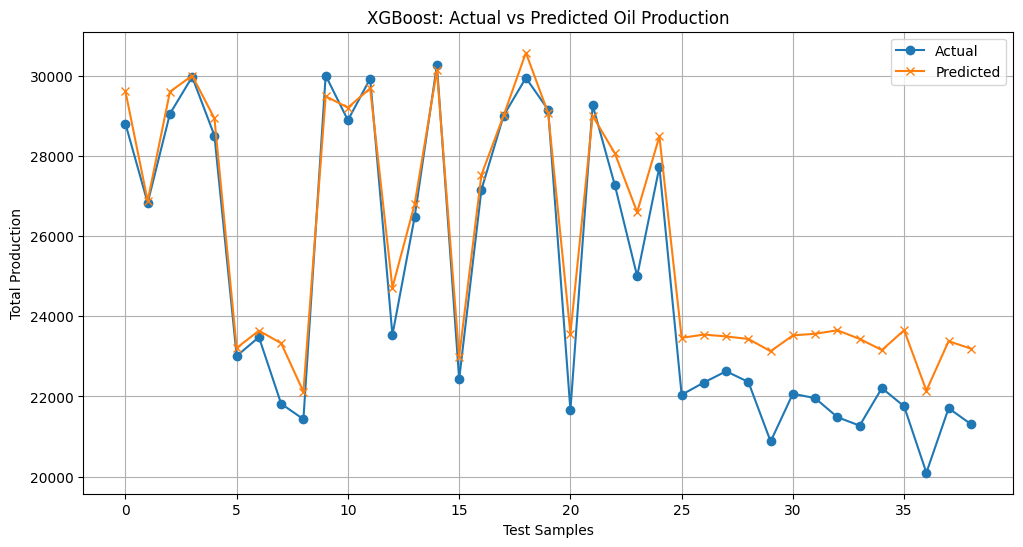

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual",
    marker="o"
)

plt.plot(
    xgb_predictions,
    label="Predicted",
    marker="x"
)

plt.title("XGBoost: Actual vs Predicted Oil Production")

plt.xlabel("Test Samples")

plt.ylabel("Total Production")

plt.legend()

plt.grid(True)

plt.show()

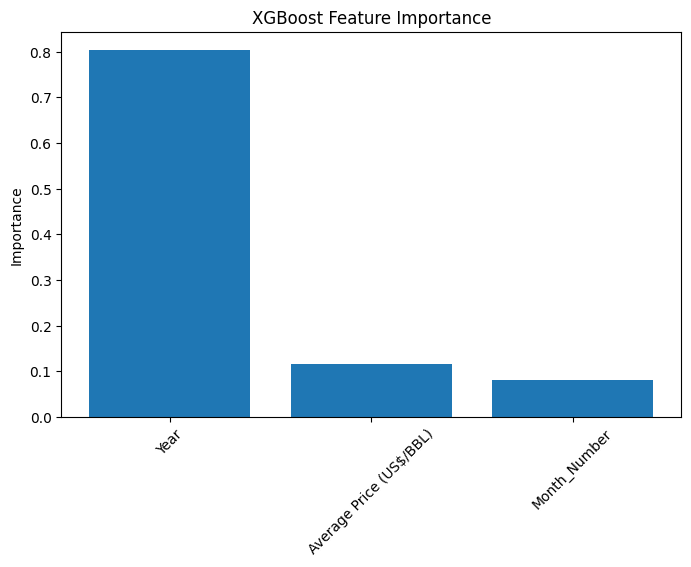

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

XGBoost Results

The XGBoost model was trained using the selected input features to predict total monthly oil production.

The model was evaluated using:

• Mean Absolute Error (MAE)
• Root Mean Squared Error (RMSE)
• Mean Absolute Percentage Error (MAPE)
• R² Score

The performance of XGBoost will be compared with Linear Regression and Random Forest to determine the most accurate forecasting model for Oman's monthly oil production.

#Model Comparison

Model Comparison

The three machine learning models were evaluated using four performance metrics:

• Mean Absolute Error (MAE)
• Root Mean Squared Error (RMSE)
• Mean Absolute Percentage Error (MAPE)
• Coefficient of Determination (R²)

Lower values of MAE, RMSE and MAPE indicate better predictive performance, whereas a higher R² score indicates a stronger fit between predicted and actual values.

In [ ]:
comparison_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        mape * 100,
        rf_mape * 100,
        xgb_mape * 100
    ],

    "R²": [
        r2,
        rf_r2,
        xgb_r2
    ]

})

comparison_results

,Model,MAE,RMSE,MAPE (%),R²
0,Linear Regression,2036.192390,2382.288496,8.918568,0.523807
1,Random Forest,1219.328808,1500.934685,5.350392,0.810976
2,XGBoost,942.922696,1174.900468,4.145414,0.884177


In [ ]:
comparison_results = comparison_results.round(2)

comparison_results

,Model,MAE,RMSE,MAPE (%),R²
0,Linear Regression,2036.19,2382.29,8.92,0.52
1,Random Forest,1219.33,1500.93,5.35,0.81
2,XGBoost,942.92,1174.90,4.15,0.88


In [ ]:
best_model = comparison_results.loc[
    comparison_results["R²"].idxmax()
]

print("Best Performing Model:")

print(best_model)

Best Performing Model:
Model       XGBoost
MAE          942.92
RMSE         1174.9
MAPE (%)       4.15
R²             0.88
Name: 2, dtype: object


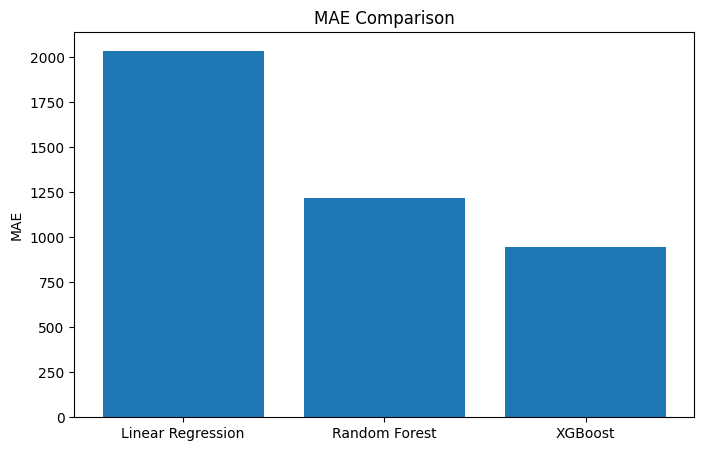

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_results["Model"],
    comparison_results["MAE"]
)

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.show()

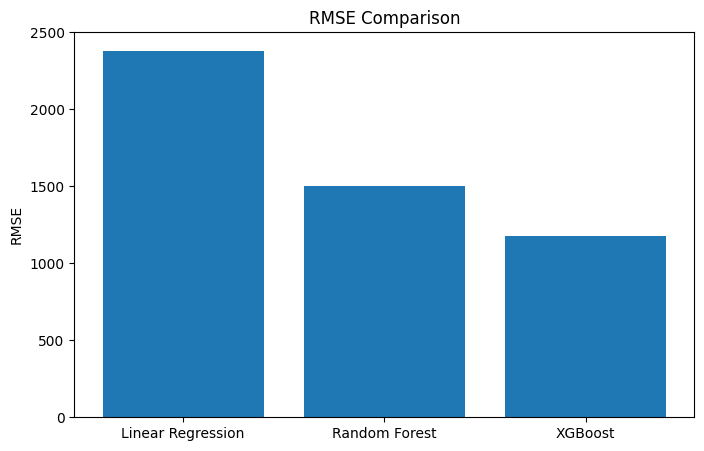

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_results["Model"],
    comparison_results["RMSE"]
)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

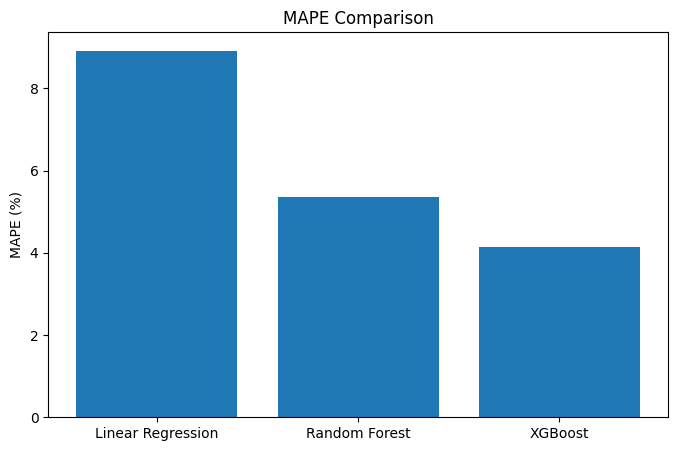

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_results["Model"],
    comparison_results["MAPE (%)"]
)

plt.title("MAPE Comparison")

plt.ylabel("MAPE (%)")

plt.show()

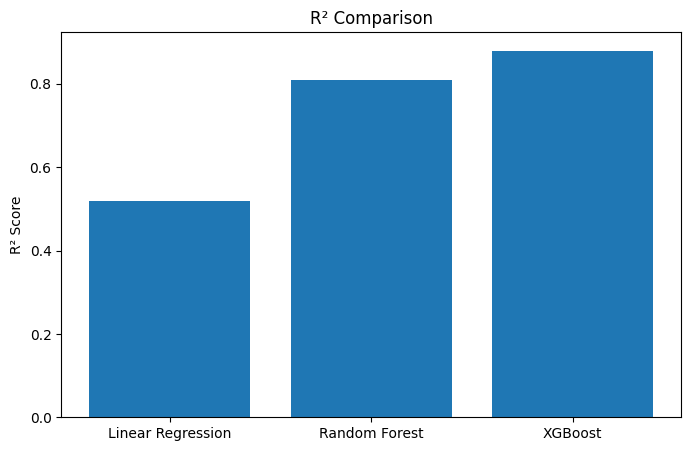

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_results["Model"],
    comparison_results["R²"]
)

plt.title("R² Comparison")

plt.ylabel("R² Score")

plt.show()

#Conclusion

Model Comparison Summary

The three machine learning algorithms were compared using four commonly used regression evaluation metrics.

The model with the lowest MAE, RMSE and MAPE together with the highest R² score was considered the best-performing forecasting model.

The comparison enables the identification of the most suitable machine learning algorithm for forecasting Oman's monthly oil production and provides evidence for selecting the most appropriate model for future forecasting applications.

Conclusion

This study compared the forecasting performance of Linear Regression, Random Forest and XGBoost using Oman's monthly oil production dataset.

The models were evaluated using MAE, RMSE, MAPE and R² to determine forecasting accuracy.

The findings identify the machine learning model that provides the most accurate predictions and demonstrate how data-driven forecasting techniques can support decision-making within Oman's oil and gas sector.

The results also contribute to the objectives of Oman Vision 2040 by highlighting the potential of artificial intelligence and machine learning for improving digital transformation and predictive analytics in the national energy industry.